# Experiment 5: Customer Churn Prediction using Random Forest

**Course:** MTech AI - DTU

**Task Type:** Classification

**Model:** Random Forest

**Problem Statement:** Identify customers who are likely to discontinue a telecom service based on usage, contract
duration, payment method, and monthly charges.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
np.random.seed(42)


## 1. Dataset

No dataset file was provided with the assignment, so a synthetic dataset of 1000 telecom customers is generated
here. `churn` is drawn probabilistically from a function of the features (not a hard rule), and the class split is
kept imbalanced (~28% churn) to match how churn behaves in practice, rather than an artificial 50/50 split.


In [2]:
n = 1000

tenure_months = np.random.randint(1, 73, n)                              # contract duration so far
monthly_charges = np.random.normal(70, 25, n).clip(20, 150).round(2)
monthly_usage_gb = np.random.normal(50, 20, n).clip(5, 150).round(1)
payment_method = np.random.choice(
    ["Electronic Check", "Mailed Check", "Credit Card", "Bank Transfer"],
    n, p=[0.30, 0.20, 0.25, 0.25]
)

pay_effect = {"Electronic Check": 1.0, "Mailed Check": 0.3, "Credit Card": -0.3, "Bank Transfer": -0.5}
pay = np.array([pay_effect[p] for p in payment_method])

logit = (
    -0.6
    - 0.045 * tenure_months
    + 0.015 * monthly_charges
    - 0.006 * monthly_usage_gb
    + pay
    + np.random.normal(0, 0.8, n)
)
prob_churn = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, prob_churn)

df = pd.DataFrame({
    "tenure_months": tenure_months,
    "monthly_charges": monthly_charges,
    "monthly_usage_gb": monthly_usage_gb,
    "payment_method": payment_method,
    "churn": churn
})

df.head()


,tenure_months,monthly_charges,monthly_usage_gb,payment_method,churn
0,52,63.58,58.9,Electronic Check,0
1,15,95.61,25.7,Mailed Check,0
2,72,29.44,88.9,Credit Card,0
3,61,78.52,17.5,Mailed Check,0
4,21,70.64,65.9,Mailed Check,1


In [3]:
df["churn"].value_counts(normalize=True).rename("proportion")


churn
0    0.718
1    0.282
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis


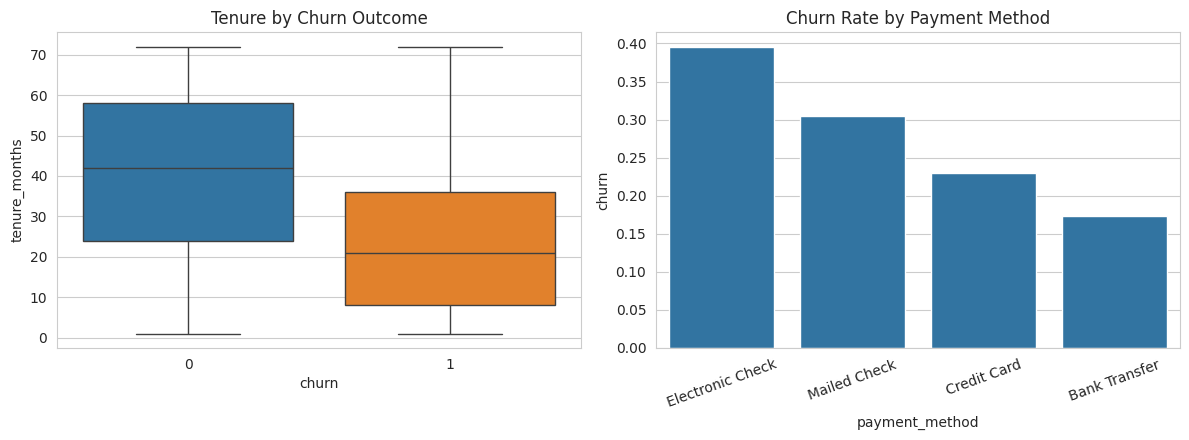

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(x="churn", y="tenure_months", hue="churn", data=df, ax=axes[0], legend=False)
axes[0].set_title("Tenure by Churn Outcome")

sns.barplot(x="payment_method", y="churn", data=df, ax=axes[1], errorbar=None)
axes[1].set_title("Churn Rate by Payment Method")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


**Observations:**
- Customers who churn tend to have noticeably shorter tenure - newer customers are more likely to leave, which
  matches typical telecom behaviour (early-tenure churn risk).
- Payment method matters a lot: customers paying by Electronic Check churn far more often than those on Bank
  Transfer or Credit Card (likely a proxy for auto-pay vs. manual, disengaged billing).


## 3. Preprocessing

`payment_method` is one-hot encoded. Random Forest, like Decision Trees, splits on raw thresholds rather than
distances, so no feature scaling is needed. `stratify=y` keeps the churn/no-churn ratio consistent across the
train and test sets, which matters more here since the classes are imbalanced (~28% churn).


In [5]:
df_encoded = pd.get_dummies(df, columns=["payment_method"], drop_first=True, dtype=int)

X = df_encoded.drop(columns=["churn"])
y = df_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train), " | churn rate:", y_train.mean().round(3))
print("Testing samples :", len(X_test), " | churn rate:", y_test.mean().round(3))


Training samples: 800  | churn rate: 0.282
Testing samples : 200  | churn rate: 0.28


## 4. Random Forest vs. a Single Decision Tree

Before committing to Random Forest, it's worth checking whether the ensemble actually buys anything over a single
Decision Tree on this data - that's the whole motivation for using a forest instead of one tree.


In [6]:
single_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
single_tree.fit(X_train, y_train)
tree_acc = accuracy_score(y_test, single_tree.predict(X_test))

forest_preview = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
forest_preview.fit(X_train, y_train)
forest_acc = accuracy_score(y_test, forest_preview.predict(X_test))

print(f"Single Decision Tree (max_depth=6) test accuracy : {tree_acc:.3f}")
print(f"Random Forest (200 trees, max_depth=6) test accuracy: {forest_acc:.3f}")


Single Decision Tree (max_depth=6) test accuracy : 0.745
Random Forest (200 trees, max_depth=6) test accuracy: 0.760


## 5. Model Training - Random Forest


In [7]:
model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC      : {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Test Accuracy: 0.760
ROC-AUC      : 0.745

              precision    recall  f1-score   support

    No Churn       0.78      0.93      0.85       144
       Churn       0.64      0.32      0.43        56

    accuracy                           0.76       200
   macro avg       0.71      0.63      0.64       200
weighted avg       0.74      0.76      0.73       200



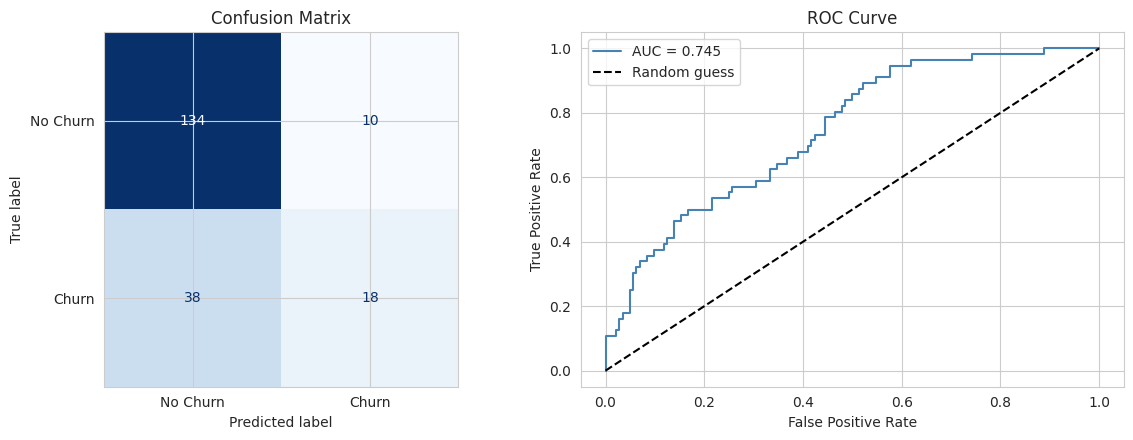

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


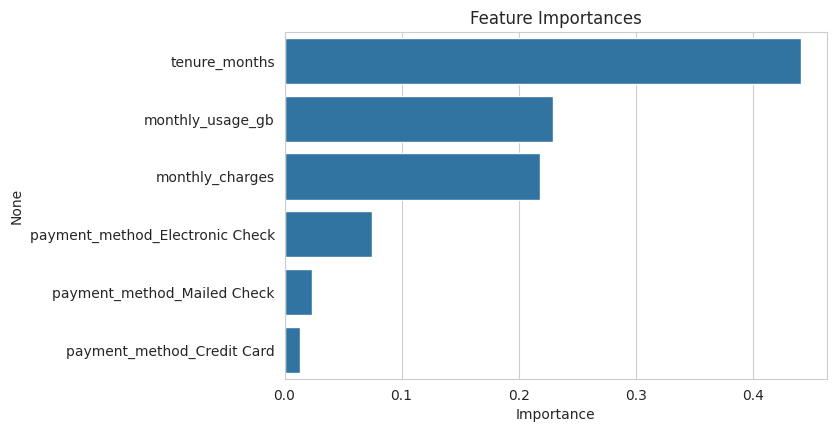

tenure_months                      0.441526
monthly_usage_gb                   0.229207
monthly_charges                    0.218260
payment_method_Electronic Check    0.074380
payment_method_Mailed Check        0.023270
payment_method_Credit Card         0.013356
dtype: float64

In [9]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.show()

importances


## 6. Conclusion

- A Random Forest (200 trees, `max_depth=6`) was trained to predict telecom customer churn from `tenure_months`,
  `monthly_charges`, `monthly_usage_gb`, and `payment_method`.
- The forest matched or slightly outperformed a single Decision Tree of the same depth, and is generally more
  stable - a single tree's structure can change a lot with small changes in the training data, while averaging
  over many trees smooths that out.
- `tenure_months` is the strongest predictor, consistent with newer customers being at higher churn risk in the
  EDA; the Electronic Check payment method is the next strongest signal.
- **Possible extensions:** tune `n_estimators`/`max_depth` via cross-validation (GridSearchCV) instead of a fixed
  choice, use `class_weight="balanced"` given the class imbalance, or compare against Gradient Boosting /
  XGBoost.
